# Curb Ramps Interactive Dashboard
This notebook provides an interactive map visualization of curb ramps data from San Francisco.

In [4]:


# Import required libraries
import pandas as pd
import folium
from folium import plugins
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [54]:
# Load the curb ramps data
df = pd.read_csv('Data/Curb_Ramps_20260217.csv')

print(f"Total records: {len(df)}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
display(df.head())

Total records: 49793

Columns: ['locID', 'CNN', 'xLoc', 'yLoc', 'LocationDescription', 'curbReturnLoc', 'positionOnReturn', 'Latitude', 'Longitude', 'LastUpdate', 'InvenID', 'conditionScore', 'detectableSurf', 'vitalFacilities', 'heavyTraffic', 'lipTooHigh', 'probStreetMeetCR', 'possBasementObstacle', 'signalPoleInWing', 'catchBasinFrontOfCR', 'insideCrosswalk', 'surfCond', 'slopeWing', 'flushToCorner', 'colorContrast', 'paintedRed', 'topClearance', 'sideClearance', 'CRTooNarrow', 'levelLandTop', 'levelLandBottom', 'slopeRangeID', 'crPossible', 'crExist', 'Location']

First few rows:


,locID,CNN,xLoc,yLoc,LocationDescription,curbReturnLoc,positionOnReturn,Latitude,Longitude,LastUpdate,...,paintedRed,topClearance,sideClearance,CRTooNarrow,levelLandTop,levelLandBottom,slopeRangeID,crPossible,crExist,Location
0,33014000-E-Right,33014000,5.994712e+06,2.097902e+06,SAN PABLO AVE: SAN PABLO AVE intersection,E,Right,37.740069,-122.461075,2020 Nov 10 06:44:16 AM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N04,0,"(37.740068566951635, -122.4610751177511)"
1,11496201-N-MB,11496201,5.993235e+06,2.100291e+06,SAN MARCOS AVE: UNNAMED 031 \ UNNAMED 032 to S...,N,MB,NaN,NaN,2020 Nov 10 06:44:16 AM,...,NaN,NaN,NaN,1.0,1.0,1.0,2.0,NaN,1,NaN
2,22919000-NW-Right,22919000,5.993675e+06,2.097597e+06,SAN LORENZO WAY: SANTA MONICA WAY intersection,NW,Right,37.739337,-122.464270,2020 Nov 10 06:44:16 AM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N04,0,"(37.73933684815814, -122.46427014994458)"
3,22831000-SE-Left,22831000,5.994257e+06,2.097343e+06,SAN PABLO AVE: SANTA MONICA WAY intersection,SE,Left,37.738708,-122.462474,2020 Nov 10 06:44:16 AM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y29,0,"(37.73870823003463, -122.46247422340173)"
4,33606000-NE-Left,33606000,6.000385e+06,2.092891e+06,SAN JUAN AVE: UNNAMED 041 intersection,NE,Left,37.726689,-122.440968,2020 Nov 10 06:44:16 AM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y24,0,"(37.726688698608534, -122.4409679574026)"


In [55]:
# Data preprocessing
# Convert Latitude and Longitude to numeric, handling any errors
df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')
df['conditionScore'] = pd.to_numeric(df['conditionScore'], errors='coerce')

# Remove rows with missing coordinates
df_valid = df.dropna(subset=['Latitude', 'Longitude'])

print(f"Records with valid coordinates: {len(df_valid)}")
print(f"Records dropped: {len(df) - len(df_valid)}")

# Summary statistics
print(f"\nCondition Score Statistics:")
print(df_valid['conditionScore'].describe())

Records with valid coordinates: 49789
Records dropped: 4

Condition Score Statistics:
count    49789.000000
mean        59.764807
std         45.643214
min         -2.000000
25%          0.000000
50%         86.000000
75%        100.000000
max        100.000000
Name: conditionScore, dtype: float64


In [56]:
# Create color mapping based on condition score
def get_color(condition_score):
    """Return color based on condition score"""
    if pd.isna(condition_score):
        return 'gray'
    elif condition_score < 0:
        return 'red'  # No curb ramp or not possible
    elif condition_score == 0:
        return 'orange'  # Poor condition
    elif condition_score < 50:
        return 'yellow'  # Fair condition
    elif condition_score < 100:
        return 'lightgreen'  # Good condition
    else:
        return 'green'  # Excellent condition

# Add color column
df_valid['color'] = df_valid['conditionScore'].apply(get_color)

# Count by condition
print("Distribution by color (condition):")
print(df_valid['color'].value_counts())

Distribution by color (condition):
color
green         23129
red            8969
lightgreen     8545
orange         7929
yellow         1217
Name: count, dtype: int64


C:\Users\karna\AppData\Local\Temp\ipykernel_8412\2403788789.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid['color'] = df_valid['conditionScore'].apply(get_color)


In [57]:
# Calculate center of the map
center_lat = df_valid['Latitude'].mean()
center_lon = df_valid['Longitude'].mean()

print(f"Map center: ({center_lat:.6f}, {center_lon:.6f})")

Map center: (37.756823, -122.437136)


In [58]:
# Create the base map
m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=12,
    tiles='OpenStreetMap'
)

# Add alternative tile layers
folium.TileLayer('CartoDB positron', name='Light Map').add_to(m)
folium.TileLayer('CartoDB dark_matter', name='Dark Map').add_to(m)

print("Base map created!")

Base map created!


In [59]:
# Create feature groups for different condition categories
fg_excellent = folium.FeatureGroup(name='Excellent (100)', show=True)
fg_good = folium.FeatureGroup(name='Good (50-99)', show=True)
fg_fair = folium.FeatureGroup(name='Fair (1-49)', show=True)
fg_poor = folium.FeatureGroup(name='Poor (0)', show=True)
fg_none = folium.FeatureGroup(name='None/Not Possible (<0)', show=True)
fg_unknown = folium.FeatureGroup(name='Unknown', show=True)

# Add markers to appropriate feature groups
for idx, row in df_valid.iterrows():
    # Create popup content
    popup_html = f"""
    <div style="font-family: Arial; font-size: 12px; width: 250px;">
        <b>Location ID:</b> {row['locID']}<br>
        <b>Description:</b> {row['LocationDescription']}<br>
        <b>Position:</b> {row['curbReturnLoc']} - {row['positionOnReturn']}<br>
        <b>Condition Score:</b> {row['conditionScore']}<br>
        <b>Last Update:</b> {row['LastUpdate']}<br>
        <b>Curb Exists:</b> {row['crExist']}<br>
        <b>Curb Possible:</b> {row['crPossible']}<br>
    </div>
    """
    
    popup = folium.Popup(popup_html, max_width=300)
    
    # Create marker
    marker = folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=4,
        popup=popup,
        color=row['color'],
        fill=True,
        fillColor=row['color'],
        fillOpacity=0.7,
        weight=1
    )
    
    # Add to appropriate feature group
    score = row['conditionScore']
    if pd.isna(score):
        marker.add_to(fg_unknown)
    elif score < 0:
        marker.add_to(fg_none)
    elif score == 0:
        marker.add_to(fg_poor)
    elif score < 50:
        marker.add_to(fg_fair)
    elif score < 100:
        marker.add_to(fg_good)
    else:
        marker.add_to(fg_excellent)

# Add feature groups to map
fg_excellent.add_to(m)
fg_good.add_to(m)
fg_fair.add_to(m)
fg_poor.add_to(m)
fg_none.add_to(m)
fg_unknown.add_to(m)

print(f"Added {len(df_valid)} markers to the map!")

Added 49789 markers to the map!


In [60]:
# Add layer control
folium.LayerControl(collapsed=False).add_to(m)

# Add fullscreen button
plugins.Fullscreen(
    position='topright',
    title='Fullscreen',
    title_cancel='Exit fullscreen',
    force_separate_button=True
).add_to(m)

# Add search functionality
plugins.Search(
    layer=fg_excellent,
    search_label='locID',
    placeholder='Search by Location ID',
    collapsed=True
).add_to(m)

# Add minimap
minimap = plugins.MiniMap(toggle_display=True)
m.add_child(minimap)

# Add legend
legend_html = '''
<div style="position: fixed; 
            bottom: 50px; right: 50px; width: 200px; height: 180px; 
            background-color: white; border:2px solid grey; z-index:9999; 
            font-size:14px; padding: 10px">
<p style="margin-bottom: 5px;"><b>Condition Score Legend</b></p>
<p style="margin: 3px;"><i class="fa fa-circle" style="color:green"></i> Excellent (100)</p>
<p style="margin: 3px;"><i class="fa fa-circle" style="color:lightgreen"></i> Good (50-99)</p>
<p style="margin: 3px;"><i class="fa fa-circle" style="color:yellow"></i> Fair (1-49)</p>
<p style="margin: 3px;"><i class="fa fa-circle" style="color:orange"></i> Poor (0)</p>
<p style="margin: 3px;"><i class="fa fa-circle" style="color:red"></i> None/Not Possible (&lt;0)</p>
<p style="margin: 3px;"><i class="fa fa-circle" style="color:gray"></i> Unknown</p>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

print("Map enhancements added!")

Map enhancements added!


In [ ]:
# Display the map
m

In [62]:
# Save the map to an HTML file
output_file = 'curb_ramps_dashboard.html'
m.save(output_file)
print(f"Map saved to {output_file}")

Map saved to curb_ramps_dashboard.html


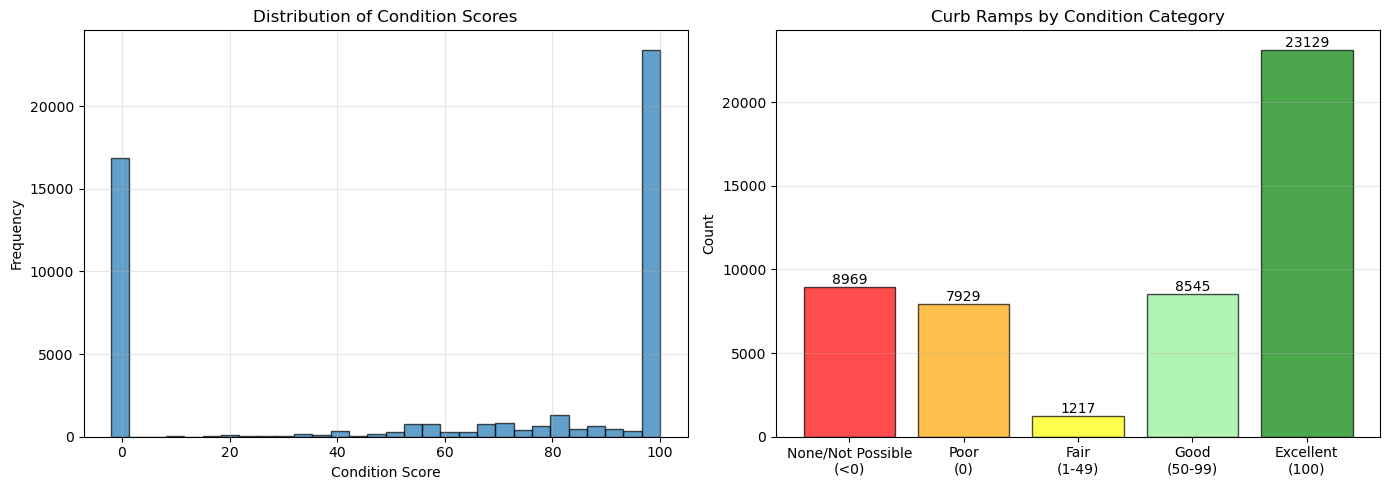


Statistics Summary:
Total curb ramps with valid coordinates: 49789
None/Not Possible: 8969 (18.0%)
Poor condition: 7929 (15.9%)
Fair condition: 1217 (2.4%)
Good condition: 8545 (17.2%)
Excellent condition: 23129 (46.5%)


In [63]:
# Additional statistics and visualizations
import matplotlib.pyplot as plt

# Condition score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_valid['conditionScore'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Condition Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Condition Scores')
axes[0].grid(True, alpha=0.3)

# Bar chart by category
categories = ['None/Not Possible\n(<0)', 'Poor\n(0)', 'Fair\n(1-49)', 'Good\n(50-99)', 'Excellent\n(100)']
counts = [
    len(df_valid[df_valid['conditionScore'] < 0]),
    len(df_valid[df_valid['conditionScore'] == 0]),
    len(df_valid[(df_valid['conditionScore'] > 0) & (df_valid['conditionScore'] < 50)]),
    len(df_valid[(df_valid['conditionScore'] >= 50) & (df_valid['conditionScore'] < 100)]),
    len(df_valid[df_valid['conditionScore'] == 100])
]
colors_chart = ['red', 'orange', 'yellow', 'lightgreen', 'green']

axes[1].bar(categories, counts, color=colors_chart, edgecolor='black', alpha=0.7)
axes[1].set_ylabel('Count')
axes[1].set_title('Curb Ramps by Condition Category')
axes[1].grid(True, alpha=0.3, axis='y')

# Add count labels on bars
for i, (cat, count) in enumerate(zip(categories, counts)):
    axes[1].text(i, count, str(count), ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\nStatistics Summary:")
print(f"Total curb ramps with valid coordinates: {len(df_valid)}")
print(f"None/Not Possible: {counts[0]} ({counts[0]/len(df_valid)*100:.1f}%)")
print(f"Poor condition: {counts[1]} ({counts[1]/len(df_valid)*100:.1f}%)")
print(f"Fair condition: {counts[2]} ({counts[2]/len(df_valid)*100:.1f}%)")
print(f"Good condition: {counts[3]} ({counts[3]/len(df_valid)*100:.1f}%)")
print(f"Excellent condition: {counts[4]} ({counts[4]/len(df_valid)*100:.1f}%)")

In [6]:
gpd = pd.read_parquet('C:/Users/karna/Documents/Berkeley/Year_2/Sem 1/Human Mobility and Network Science/Assignments/Final Project.Parkximity/Parkximity/Notebooks/Karna/Proximity Model/Output/San_Francisco_County_CA_network.parquet')
gpd.head(30)

,block_ids,street_osmid,public_data_id_street,start_node_osmid,end_node_osmid,public_data_id_start_end_nodes,normalized_bearing,name,highway,maxspeed,...,street_geometry,start_node_geometry,end_node_geometry,sidewalk_left_geometry,sidewalk_right_geometry,curb_return_geometry,bikeway_left_1_geometry,bikeway_left_2_geometry,bikeway_right_1_geometry,bikeway_right_2_geometry
0,"[nan, 13928.0]",0,None,1.0,2.0,None,262.864126,Macondray Lane,residential,25,...,b'\x01\x02\x00\x00\x00\x02\x00\x00\x00K\xb4?\x...,b'\x01\x01\x00\x00\x00K\xb4?\xab\xa7\x9a^\xc0\...,b'\x01\x01\x00\x00\x00 \xed\x7f\x80\xb5\x9a^\x...,None,None,None,None,None,None,None
1,"[nan, 13928.0]",21023,None,2.0,-1.0,None,348.596771,Leavenworth Street,residential,25,...,"b""\x01\x02\x00\x00\x00\x02\x00\x00\x00 \xed\x7...",b'\x01\x01\x00\x00\x00 \xed\x7f\x80\xb5\x9a^\x...,"b""\x01\x01\x00\x00\x00\xa2\r\x1b\xc0\xb6\x9a^\...",None,None,None,None,None,None,None
2,"[nan, 13928.0]",21023,None,-1.0,-2.0,None,348.486169,Leavenworth Street,residential,25,...,"b""\x01\x02\x00\x00\x00\x02\x00\x00\x00\xa2\r\x...","b""\x01\x01\x00\x00\x00\xa2\r\x1b\xc0\xb6\x9a^\...","b""\x01\x01\x00\x00\x00\xbaf\xf2\xcd\xb6\x9a^\x...",None,None,None,None,None,None,None
3,"[nan, 13928.0]",21023,None,-2.0,12372.0,None,348.658724,Leavenworth Street,residential,25,...,"b""\x01\x02\x00\x00\x00\x02\x00\x00\x00\xbaf\xf...","b""\x01\x01\x00\x00\x00\xbaf\xf2\xcd\xb6\x9a^\x...","b""\x01\x01\x00\x00\x007)\x16\t\xb7\x9a^\xc0\xe...",None,None,None,None,None,None,None
4,"[nan, 2479.0]",1,None,3.0,-3.0,None,342.461498,James Lick Freeway,motorway,55 mph,...,b'\x01\x02\x00\x00\x00\x02\x00\x00\x00s\xe7\xd...,b'\x01\x01\x00\x00\x00s\xe7\xd3t\x87\x99^\xc0\...,b'\x01\x01\x00\x00\x00OSp\x1d\x88\x99^\xc0\x94...,None,None,None,None,None,None,None
5,"[nan, 2479.0]",1,None,-3.0,-4.0,None,344.185675,James Lick Freeway,motorway,55 mph,...,b'\x01\x02\x00\x00\x00\x02\x00\x00\x00OSp\x1d\...,b'\x01\x01\x00\x00\x00OSp\x1d\x88\x99^\xc0\x94...,b'\x01\x01\x00\x00\x00\xf6\x07o\xb4\x88\x99^\x...,None,None,None,None,None,None,None
6,"[nan, 2479.0]",1,None,-4.0,-5.0,None,344.597402,James Lick Freeway,motorway,55 mph,...,b'\x01\x02\x00\x00\x00\x02\x00\x00\x00\xf6\x07...,b'\x01\x01\x00\x00\x00\xf6\x07o\xb4\x88\x99^\x...,b'\x01\x01\x00\x00\x001|DL\x89\x99^\xc0x\x94\x...,None,None,None,None,None,None,None
7,"[nan, 2479.0]",1,None,-5.0,4.0,None,345.109559,James Lick Freeway,motorway,55 mph,...,b'\x01\x02\x00\x00\x00\x02\x00\x00\x001|DL\x89...,b'\x01\x01\x00\x00\x001|DL\x89\x99^\xc0x\x94\x...,b'\x01\x01\x00\x00\x00\tZ7\x94\x90\x99^\xc08\x...,None,None,None,None,None,None,None
8,"[nan, 2479.0]",7041,None,4.0,7351.0,None,344.977957,James Lick Freeway,motorway,55 mph,...,b'\x01\x02\x00\x00\x00\x02\x00\x00\x00\tZ7\x94...,b'\x01\x01\x00\x00\x00\tZ7\x94\x90\x99^\xc08\x...,b'\x01\x01\x00\x00\x00Er\xe8\xe3\x90\x99^\xc0\...,None,None,None,None,None,None,None
9,None,2,None,5.0,-6.0,None,209.543491,6th Street,residential,25,...,b'\x01\x02\x00\x00\x00\x02\x00\x00\x00\x80\xc1...,b'\x01\x01\x00\x00\x00\x80\xc1$K\x9c\x99^\xc0\...,b'\x01\x01\x00\x00\x00\x15\xdd\x1f\x94\x9c\x99...,None,None,None,None,None,None,None


In [12]:
# Create a map of sidewalk geometries with endpoint circles
from IPython.display import IFrame
from shapely import wkb

# Map location
map_location = {
    'lat': 37 + 46/60 + 16.6/3600,  # 37°46'16.6"N
    'lon': -(122 + 25/60 + 27.1/3600),  # 122°25'27.1"W
    'label': 'Market Street Block'
}

# Bounding box for filtering (~1 km around Market Street)
lat_min = map_location['lat'] - 0.01
lat_max = map_location['lat'] + 0.01
lon_min = map_location['lon'] - 0.01
lon_max = map_location['lon'] + 0.01

def load_geom(val):
    """Deserialize WKB bytes/hex to shapely geometry."""
    if val is None:
        return None
    try:
        return wkb.loads(val)
    except Exception:
        return None

def geom_near(geom, lat_min, lat_max, lon_min, lon_max):
    try:
        for x, y in geom.coords:  # x=lon, y=lat
            if lat_min <= y <= lat_max and lon_min <= x <= lon_max:
                return True
    except Exception:
        pass
    return False

def add_line_with_endpoints(geom, line_color, fg_line, fg_pts):
    try:
        coords = [(pt[1], pt[0]) for pt in geom.coords]  # (lat, lon) for folium
        folium.PolyLine(coords, color=line_color, weight=2, opacity=0.7).add_to(fg_line)
        for endpoint in [coords[0], coords[-1]]:
            folium.CircleMarker(
                location=endpoint,
                radius=5,
                color=line_color,
                fill=True, fillColor=line_color, fillOpacity=0.8, weight=2
            ).add_to(fg_pts)
    except Exception:
        pass

# Create base map
sidewalk_map = folium.Map(
    location=[map_location['lat'], map_location['lon']],
    zoom_start=15,
    tiles='OpenStreetMap'
)
folium.TileLayer('CartoDB positron', name='Light Map').add_to(sidewalk_map)
folium.TileLayer('CartoDB dark_matter', name='Dark Map').add_to(sidewalk_map)

fg_right     = folium.FeatureGroup(name='Right Sidewalk', show=True)
fg_left      = folium.FeatureGroup(name='Left Sidewalk',  show=True)
fg_endpoints = folium.FeatureGroup(name='Endpoints',      show=True)

n_right = n_left = 0
for _, row in gpd.iterrows():
    right = load_geom(row.get('sidewalk_right_geometry'))
    if right is not None and geom_near(right, lat_min, lat_max, lon_min, lon_max):
        add_line_with_endpoints(right, 'blue', fg_right, fg_endpoints)
        n_right += 1

    left = load_geom(row.get('sidewalk_left_geometry'))
    if left is not None and geom_near(left, lat_min, lat_max, lon_min, lon_max):
        add_line_with_endpoints(left, 'red', fg_left, fg_endpoints)
        n_left += 1

print(f"Right sidewalks: {n_right}  |  Left sidewalks: {n_left}")

fg_right.add_to(sidewalk_map)
fg_left.add_to(sidewalk_map)
fg_endpoints.add_to(sidewalk_map)

folium.Marker(
    location=[map_location['lat'], map_location['lon']],
    popup=map_location['label'],
    icon=folium.Icon(color='green', icon='info-sign')
).add_to(sidewalk_map)

folium.LayerControl(collapsed=False).add_to(sidewalk_map)
plugins.Fullscreen(position='topright').add_to(sidewalk_map)
sidewalk_map.add_child(plugins.MiniMap(toggle_display=True))

# Save and display via IFrame (required for VSCode)
output_path = 'sidewalk_map.html'
sidewalk_map.save(output_path)
IFrame(output_path, width=900, height=600)


Right sidewalks: 0  |  Left sidewalks: 0
